In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60,random_state=42)

In [4]:
df = pd.DataFrame(X, columns=['Feature1','Feature2'])

In [5]:
df

,Feature1,Feature2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [7]:
inertia = []
K_range = range(1,11)

In [11]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [13]:
inertia

[1000.0000000000001,
 297.89541410517216,
 11.57548472310498,
 9.752067977356841,
 8.257175272446283,
 6.917577320416799,
 6.334755391595288,
 5.704177177901429,
 5.060234133532076,
 4.762361898130396]

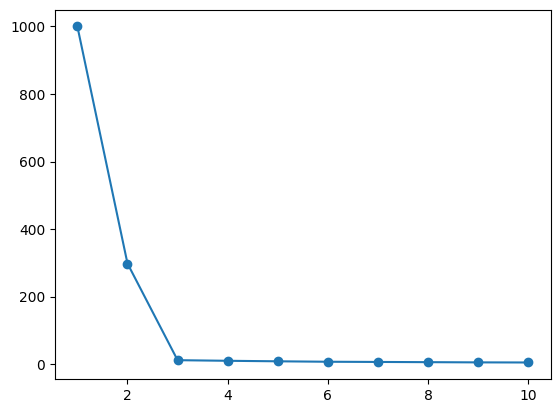

In [15]:
plt.plot(K_range,inertia, marker='o')

In [16]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [17]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [19]:
df['clusters'] = cluster_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

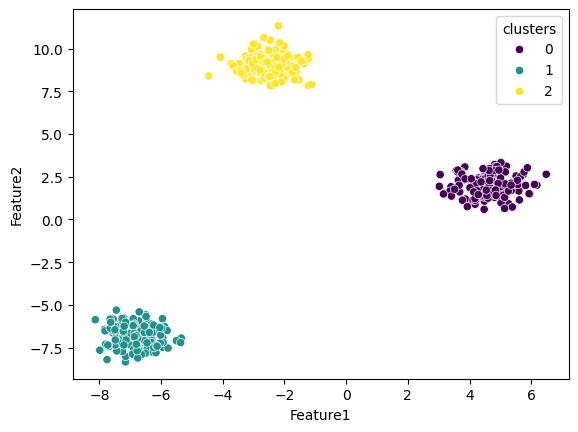

In [22]:
sns.scatterplot(x=df['Feature1'],
                y=df['Feature2'],
                hue=df['clusters'],
                palette='viridis')